In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("ahmedelsany/car-brand-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'car-brand-classification-dataset' dataset.
Path to dataset files: /kaggle/input/car-brand-classification-dataset
Contents of base_path (/kaggle/input):
['car-brand-classification-dataset']
Contents of path (/kaggle/input/car-brand-classification-dataset):
['Car Brand Classification Dataset']


In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'Car Brand Classification Dataset', 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'Car Brand Classification Dataset', 'test'))}")

Contents of the 'train' directory: ['Nissan', 'Ford', 'Hyundai', 'Mercedes-Benz', 'Chrysler', 'GMC', 'Lincoln', 'FIAT', 'Aston Martin', 'Volkswagen', 'Land Rover', 'Buick', 'Honda', 'Dodge', 'Porsche', 'Kia', 'Toyota', 'Jeep', 'Volvo', 'Mitsubishi', 'Cadillac', 'Chevrolet', 'Jaguar', 'Bentley', 'BMW', 'Lexus', 'Audi', 'INFINITI', 'Acura', 'Subaru', 'Mazda', 'Ram', 'MINI']
Contents of the 'test' directory: ['Nissan', 'Ford', 'Hyundai', 'Mercedes-Benz', 'Chrysler', 'GMC', 'Lincoln', 'FIAT', 'Aston Martin', 'Volkswagen', 'Land Rover', 'Buick', 'Honda', 'Dodge', 'Porsche', 'Kia', 'Toyota', 'Jeep', 'Volvo', 'Mitsubishi', 'Cadillac', 'Chevrolet', 'Jaguar', 'Bentley', 'BMW', 'Lexus', 'Audi', 'INFINITI', 'Acura', 'Subaru', 'Mazda', 'Ram', 'MINI']



--- Sample Images from Training Dataset (/kaggle/input/car-brand-classification-dataset/Car Brand Classification Dataset/train) ---
Found 11517 images in /kaggle/input/car-brand-classification-dataset/Car Brand Classification Dataset/train. Displaying 6 samples:


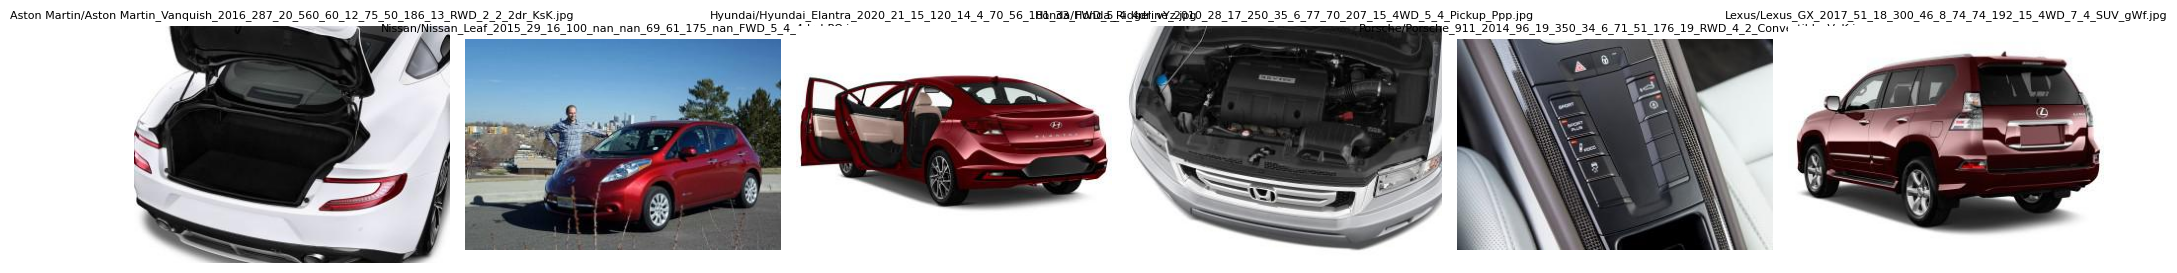


--- Sample Images from Test Dataset (/kaggle/input/car-brand-classification-dataset/Car Brand Classification Dataset/test) ---
Found 2475 images in /kaggle/input/car-brand-classification-dataset/Car Brand Classification Dataset/test. Displaying 6 samples:


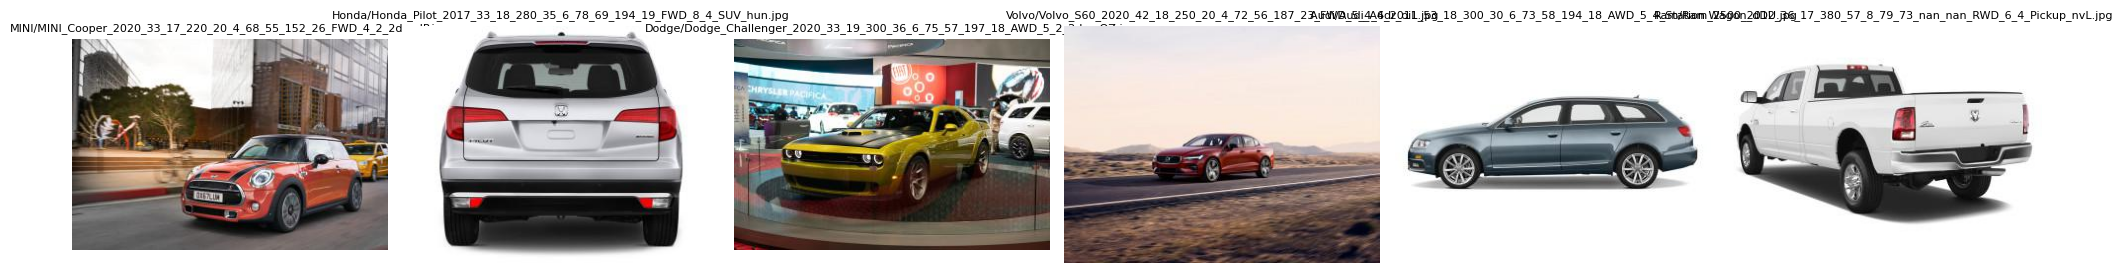

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to include 'Car Brand Classification Dataset' subdirectory
train_path = os.path.join(path, 'Car Brand Classification Dataset', 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

test_path = os.path.join(path, 'Car Brand Classification Dataset', 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

In [ ]:
import tensorflow as tf

# Check if GPU is available
print("TensorFlow version:", tf.__version__)
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Please enable GPU in Colab settings (Runtime -> Change runtime type).')
else:
  print('Found GPU at: {}'.format(device_name))

TensorFlow version: 2.20.0
Found GPU at: /device:GPU:0


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models, optimizers

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = len(os.listdir(train_path))

# Data Preparation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Build Model
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base model

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Training
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Found 9240 images belonging to 33 classes.
Found 2277 images belonging to 33 classes.
Found 2475 images belonging to 33 classes.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 268s 819ms/step - accuracy: 0.0435 - loss: 3.5040 - val_accuracy: 0.0531 - val_loss: 3.4256
Epoch 2/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 161s 556ms/step - accuracy: 0.0711 - loss: 3.3659 - val_accuracy: 0.0883 - val_loss: 3.3072
Epoch 3/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 165s 571ms/step - accuracy: 0.0852 - loss: 3.2822 - val_accuracy: 0.0953 - val_loss: 3.2757
Epoch 4/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 164s 568ms/step - accuracy: 0.1028 - loss: 3.2234 - val_accuracy: 0.1094 - val_loss: 3.2309
Epoch 5/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 161s 558ms/step - accuracy: 0.1127 - loss: 3.1886 - val_accuracy: 0.1080 - val_loss: 3.2285
Epoch 6/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 163s 566ms/step - accuracy: 0.1115 - loss: 3.1576 - val_accuracy: 0.1151 - val_loss: 3.1903
Epoch 7/10
289/289 ━━━━━━━━━

In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Summary of training results
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")

78/78 ━━━━━━━━━━━━━━━━━━━━ 25s 316ms/step - accuracy: 0.1907 - loss: 2.9175
Test Loss: 2.9175
Test Accuracy: 0.1907
Final Training Accuracy: 0.1429
Final Validation Accuracy: 0.1339


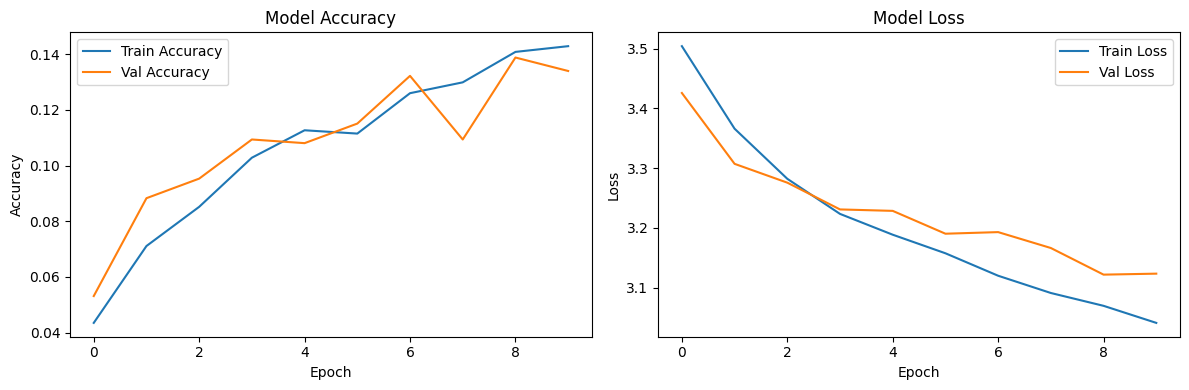

In [ ]:
import matplotlib.pyplot as plt

# Plot Training History
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()